In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix ,accuracy_score

import warnings
warnings.filterwarnings("ignore")


In [ ]:
CancerData = pd.read_csv('Cancer_data.csv')
CancerData.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
CancerData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [ ]:
CancerData.diagnosis.unique()

array(['M', 'B'], dtype=object)

In [ ]:
CancerData['diagnosis'].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

In [ ]:
M = CancerData[CancerData.diagnosis == "M"]
M.info()

<class 'pandas.core.frame.DataFrame'>
Index: 212 entries, 0 to 567
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       212 non-null    int64  
 1   diagnosis                212 non-null    object 
 2   radius_mean              212 non-null    float64
 3   texture_mean             212 non-null    float64
 4   perimeter_mean           212 non-null    float64
 5   area_mean                212 non-null    float64
 6   smoothness_mean          212 non-null    float64
 7   compactness_mean         212 non-null    float64
 8   concavity_mean           212 non-null    float64
 9   concave points_mean      212 non-null    float64
 10  symmetry_mean            212 non-null    float64
 11  fractal_dimension_mean   212 non-null    float64
 12  radius_se                212 non-null    float64
 13  texture_se               212 non-null    float64
 14  perimeter_se             212 no

In [ ]:
B = CancerData[CancerData.diagnosis == "B"]
B.info()

<class 'pandas.core.frame.DataFrame'>
Index: 357 entries, 19 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       357 non-null    int64  
 1   diagnosis                357 non-null    object 
 2   radius_mean              357 non-null    float64
 3   texture_mean             357 non-null    float64
 4   perimeter_mean           357 non-null    float64
 5   area_mean                357 non-null    float64
 6   smoothness_mean          357 non-null    float64
 7   compactness_mean         357 non-null    float64
 8   concavity_mean           357 non-null    float64
 9   concave points_mean      357 non-null    float64
 10  symmetry_mean            357 non-null    float64
 11  fractal_dimension_mean   357 non-null    float64
 12  radius_se                357 non-null    float64
 13  texture_se               357 non-null    float64
 14  perimeter_se             357 n

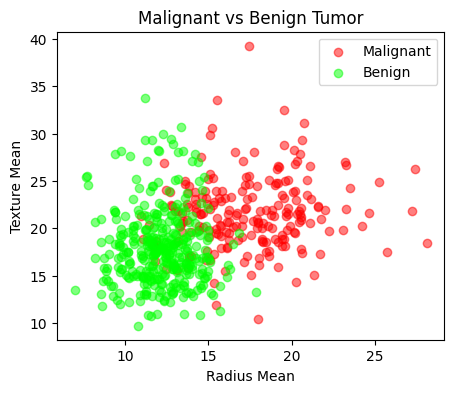

In [ ]:
plt.figure(figsize=(5,4))
plt.title("Malignant vs Benign Tumor")
plt.xlabel("Radius Mean")
plt.ylabel("Texture Mean")
plt.scatter(M.radius_mean, M.texture_mean, color = "red", label = "Malignant", alpha = 0.5)
plt.scatter(B.radius_mean, B.texture_mean, color = "lime", label = "Benign", alpha = 0.5)
plt.legend()
plt.show()

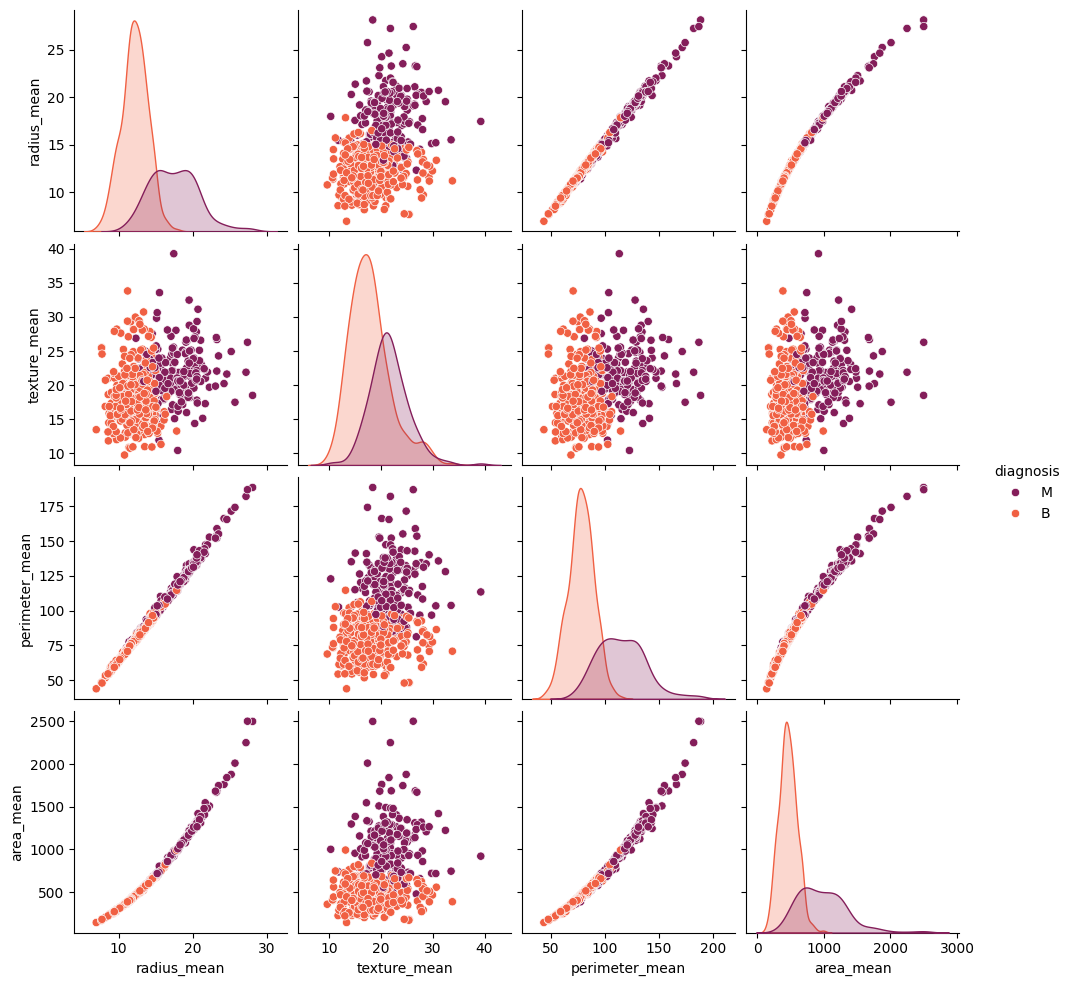

In [ ]:
cols = ['diagnosis',
        'radius_mean', 
        'texture_mean', 
        'perimeter_mean', 
        'area_mean']

sns.pairplot(data=CancerData[cols], hue='diagnosis', palette='rocket')
plt.show()

In [ ]:
CancerData['diagnosis'] = CancerData['diagnosis'].astype('category')
CancerData['class'] = CancerData['diagnosis'].cat.codes




print("Encoded data",CancerData['class'], sep="\n")

Encoded data
0      1
1      1
2      1
3      1
4      1
      ..
564    1
565    1
566    1
567    1
568    0
Name: class, Length: 569, dtype: int8


In [ ]:
CancerData=CancerData.drop(columns='diagnosis',axis=1)
CancerData.head()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,class
0,842302,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,842517,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,84300903,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,84348301,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,84358402,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


In [ ]:
X=CancerData.drop('class',axis=1)
y=CancerData['class']


In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=3) 



In [ ]:

print('Shape of X_train:',X_train.shape)
print('Shape of y_train:',y_train.shape)
print('Shape of X_test:',X_test.shape)
print('Shape of y_test:',y_test.shape)



Shape of X_train: (455, 31)
Shape of y_train: (455,)
Shape of X_test: (114, 31)
Shape of y_test: (114,)


In [ ]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
X_train = X_train.T
y_train = y_train.to_numpy()
y_train = y_train.reshape(1, X_train.shape[1])

X_test = X_test.T
y_test = y_test.to_numpy()
y_test = y_test.reshape(1, X_test.shape[1])

print('Shape of X_train:',X_train.shape)
print('Shape of y_train:',y_train.shape)
print('Shape of X_test:',X_test.shape)
print('Shape of y_test:',y_test.shape)

Shape of X_train: (31, 455)
Shape of y_train: (1, 455)
Shape of X_test: (31, 114)
Shape of y_test: (1, 114)


In [ ]:
Xtrain = X_train.T
Xtest = X_test.T

ytrain = y_train.ravel()

from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(max_iter=1000)

logreg.fit(Xtrain, ytrain)

y_pred = logreg.predict(Xtest)
print(y_pred)


[0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0
 0 1 1 1 0 0 1 0 0 1 0 1 0 1 0 0 1 1 0 0 0 0 0 0 0 1 1 0 0 1 0 1 1 0 1 1 1
 0 1 0 1 1 1 1 0 0 0 0 1 0 0 0 0 1 1 1 0 0 1 0 1 0 0 0 0 0 0 0 1 1 0 1 0 0
 1 0 0]


In [ ]:
print('Accuracy on test set: ', accuracy_score(y_test.ravel(), y_pred))


Accuracy on test set:  0.9649122807017544


In [ ]:
cm=confusion_matrix(y_test.ravel(), y_pred)
print(cm)

[[73  1]
 [ 3 37]]


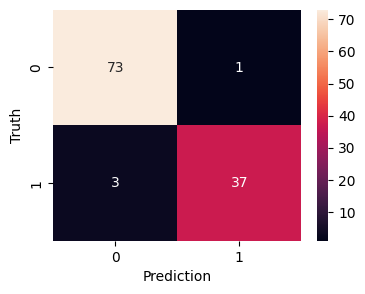

In [ ]:
plt.figure(figsize=(4,3))
sns.heatmap(cm,annot=True)
plt.ylabel("Truth")
plt.xlabel("Prediction")
plt.show()